# CSCI/MATH 485 Assignment
## Customer Churn Prediction with XGBoost
## Starter Notebook

This notebook is compatible with **Jupyter Notebook** and **Google Colab**.

This starter code is only to get you started. You can change any of the existing code here to complete all the tasks.

Complete all `TODO` sections. Make sure your final submission includes:
- data analysis,
- a tuned XGBoost model,
- your chosen main evaluation metric and justification,
- interpretation of top important features,
- and a final comparison with the baseline model.


## 1. Setup


In [2]:
# If you are using Google Colab, uncomment the next line if xgboost is not installed.
#!pip install xgboost


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier


## 2. Load the Dataset

**Instructions for students**
- Load the IBM Telco Customer Churn dataset.
- Display the first few rows.
- Confirm the dataset shape.
- If the url doesn't work for you, download the csv file from the Canvas Assignment#4

In [4]:
#url = "https://raw.githubusercontent.com/plotly/datasets/master/telco-customer-churn-by-IBM.csv"
df = pd.read_csv("telco-customer-churn-by-IBM.csv")

# Display the first 5 rows of the dataset (done below)
df.head()

# TODO:
# Display the shape of the dataset
df.shape

(7043, 21)

## 3. Data Exploration

Complete the following:
- Print all column names
- Show data types
- Count missing values in each column
- Show the distribution of the target variable
- Write a short note: Is this a classification or regression problem? Why is this useful in business?


Columns:
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn

Data types:
 Varible: customerID has a type of str
 Varible: gender has a type of str
 Varible: SeniorCitizen has a type of int64
 Varible: Partner has a type of str
 Varible: Dependents has a type of str
 Varible: tenure has a type of int64
 Varible: PhoneService has a type of str
 Varible: MultipleLines has a type of str
 Varible: InternetService has a type of str
 Varible: OnlineSecurity has a type of str
 Varible: OnlineBackup has a type of str
 Varible: DeviceProtection has a type of str
 Varible: TechSupport has a type of str
 Varible: StreamingTV has a type of str
 Varible: StreamingMovies has a type of str
 Varible: Contract has a type of str
 Varible: PaperlessBilling has a type of str
 Varible: PaymentMethod ha

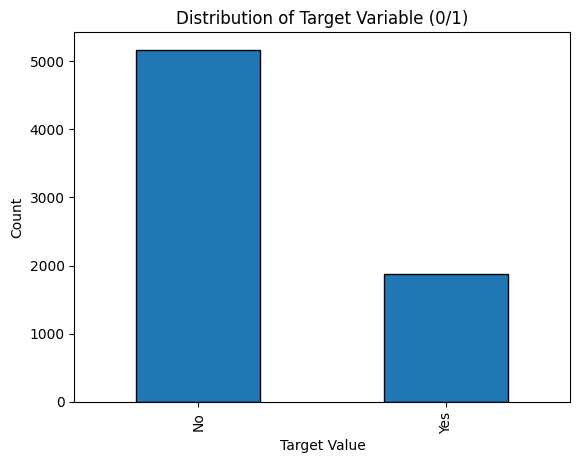

Number of churns of Yes: 1869
Number of churns of No: 5174


In [5]:
# TODO:
# Print column names
# Print data types
# Print missing values for each column
# Print value counts for the target column
import matplotlib.pyplot as plt
print("Columns:")
# your code here
for variable in df.columns:
    print(variable)
    
print("\nData types:")
# your code here
for variable in df.columns:
    print(f" Varible: {variable} has a type of {df[variable].dtype}")
    
print("\nMissing values:")
# your code here
print(df.isna().sum())

print("\nTarget distribution:")
# your code here
df["Churn"].value_counts().plot(kind="bar", edgecolor="black")
plt.xlabel("Target Value")
plt.ylabel("Count")
plt.title("Distribution of Target Variable (0/1)")
plt.show()
print(f"Number of churns of Yes: {df['Churn'].value_counts()['Yes']}")
print(f"Number of churns of No: {df['Churn'].value_counts()['No']}")

# Extra: display other information of the dataset that you think can be useful


**TODO (write your answer below):**

1. What kind of machine learning problem is this?
   
   This is a classification problem since the goal is to predict whether the customer will churn or not. In this case, a logistic regression model would be most appropriate because we are only focusing on a binary classification problem.

3. Why is churn prediction important in a business setting?
   
    Businesses need to predict customer churn because it directly protects future revenue; when a customer leaves, the company loses all potential earnings from them. Churn prediction also allows businesses to predict high‑value customers who are at risk and intervene with targeted strategies such as discounts, loyalty perks, or personalized messages. Lastly, understanding churn patterns gives companies insight into customer behavior, which they can use to improve their services and gain a competitive advantage in marketing and advertising.

## 4. Basic Cleaning

Complet the following:
- Identify whether there is an ID column that should be removed
- Convert the target column into binary form if needed
- Convert any numeric-looking columns stored as text into numeric values


In [6]:
# Make a copy so the original data remains unchanged
df_clean = df.copy()

# TODO:
# 1. Drop any unnecessary identifier column(s)
df_clean = df_clean.drop(columns=['customerID'])

# 2. Convert the target column to 0/1
df_clean["Churn"] = df_clean["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

# 3. Convert any columns that should be numeric into numeric type
df_clean["TotalCharges"] = df_clean["TotalCharges"].replace(" ", pd.NA)
df_clean["TotalCharges"] = df_clean["TotalCharges"].astype(float)
print(f"Number of NA values in Total charges: {sum(df_clean["TotalCharges"].isna())}")
# 4. Handle invalid parsing if needed

df_clean.head()


Number of NA values in Total charges: 11


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 5. Define Features and Target

Complet the following:
- Define `X` and `y`
- Set the correct target column


In [7]:
# TODO:
# Replace with the correct target column name
X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (7043, 19)
Target shape: (7043,)


## 6. Identify Numeric and Categorical Features

Complet the following:
- Create a list of numeric columns
- Create a list of categorical columns


In [8]:
# TODO:
# Identify numeric and categorical feature columns

numeric_features = []
categorical_features = []

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        numeric_features.append(col)
    else:
        categorical_features.append(col)

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 7. Train/Test Split

Complet the following:
- Split the dataset into training and testing sets
- Use stratification if appropriate


In [9]:
# TODO:
# Create train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (5634, 19)
X_test shape: (1409, 19)


## 8. Preprocessing Pipelines

Build preprocessing for:
- numeric features
- categorical features

Then combine them into a `ColumnTransformer`.


In [10]:
from sklearn.preprocessing import StandardScaler
# Since there are only 11 missing values, we only need a simple imputer
# TODO:
# Build numeric preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# TODO:
# Build categorical preprocessing pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# TODO:
# Combine both preprocessing pipelines
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 9. Baseline Model: Logistic Regression

Complet the following:
- Train a Logistic Regression model as the baseline
- Generate predictions
- Evaluate using multiple metrics
- You may need to adjust `max_iter` if the model is not converging.


In [11]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# TODO:
# Fit the baseline model
# Generate predicted labels
# Generate predicted probabilities

# your code here

# Fit the baseline model
baseline_model.fit(X_train, y_train)

# Generate predicted labels
baseline_preds = baseline_model.predict(X_test)

# Generate predicted probabilities
baseline_probs = baseline_model.predict_proba(X_test)[:,1]


In [12]:
# TODO:
# Compute and print:
# - Accuracy
# - Precision
# - Recall
# - F1-score
# - ROC-AUC
# baseline_preds
# baseline_probs

# your code here
print(f"Accuracy: {accuracy_score(y_test, baseline_preds)}")
print(f"Percision: {precision_score(y_test, baseline_preds)}")
print(f"Recall: {recall_score(y_test, baseline_preds)}")
print(f"F1 score: {f1_score(y_test, baseline_preds)}")
print(f"ROC: {roc_auc_score(y_test, baseline_probs)}")

Accuracy: 0.8055358410220014
Percision: 0.6572327044025157
Recall: 0.5588235294117647
F1 score: 0.6040462427745664
ROC: 0.8418610659019866


In [13]:
# Optional but helpful
# TODO:
# Print classification report and confusion matrix

# your code here
print(confusion_matrix(y_test, baseline_preds))
print(classification_report(y_test, baseline_preds))

[[926 109]
 [165 209]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## 10. Choose Your Main Evaluation Metric

Choose **one main metric** for this churn problem.

You must explain:
- which metric you chose,
- why it is appropriate,
- and why it is more informative than accuracy alone for this problem.


**TODO (write your answer below):**

The F1‑score is the most important evaluation metric for this churn‑prediction task.  
It combines precision and recall into a single measure of predictive performance, which matters because both components capture different types of model errors. Precision tells us how many customers were predicted to churn compared to those who actually churned. Recall tells us how many of the actual churners the model successfully identified. So then, F1-score balances these two metrics. This metric is appropriate because it is primarily used for binary classification problems, specifically in this case, distinguishing between churn and no churn. Churn datasets are also typically imbalanced because the majority of customers remain, while only a small group churns. Because of this imbalance, accuracy becomes misleading. A model that predicts no churn for every customer might achieve very high accuracy because most customers don't churn, leading to a complete failure in identifying the customers who do churn. The F1-score avoids this problem by focusing on the customers who churn. A high F1-score indicates that the model not only catches turners but also does so with high precision. 

## 11. XGBoost Model

Complet the following:
- Build an XGBoost pipeline
- Tune at least 3 hyperparameters
- Use either `GridSearchCV` or your own tuning approach


I chose these three hyperparameters because they determine how complex each tree can become, how aggressive the model learns, and how much data is required before a split is allowed. Which I deem as the most important qualities for a model.

In [14]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

# TODO:
# Define a hyperparameter grid with at least 3 hyperparameters

param_grid = {
    "classifier__max_depth": [3, 5],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__min_child_weight": [1, 3]
}

param_grid


{'classifier__max_depth': [3, 5],
 'classifier__learning_rate': [0.05, 0.1],
 'classifier__min_child_weight': [1, 3]}

I chose manual tuning because it saves time from the computation of having to run it through a grid search. I also didn't use it because I wanted to implement early stopping. This allows me to find the optimal number of trees. I also chose the tree method to be histogram-oriented because it builds a tree using histograms instead of evaluating every possible split, while being generally faster.

In [15]:
# TODO:
# Run GridSearchCV (or perform manual tuning)
# Choose a scoring metric that matches your selected main evaluation metric

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)



# Early Stopping Tuning (Manual tuning)


# Fit and transform preprocessor
preprocessor.fit(X_train)
X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)

# Split off a validation set for early stopping
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_t, y_train, test_size=0.2, random_state=42, stratify=y_train
)

results = []

for max_depth in param_grid["classifier__max_depth"]:
    for lr in param_grid["classifier__learning_rate"]:
        for mcw in param_grid["classifier__min_child_weight"]:

            model = XGBClassifier(
                max_depth=max_depth,
                learning_rate=lr,
                min_child_weight=mcw,
                n_estimators=500,
                eval_metric="logloss",
                random_state=42,
                early_stopping_rounds=20,
                tree_method='hist'
            )

            model.fit(
                X_train_split, y_train_split,
                eval_set=[(X_val, y_val)],
                verbose=False # Dont print training logs
            )

            preds = model.predict(X_val)
            f1 = f1_score(y_val, preds)

            results.append({
                "params": {
                    "max_depth": max_depth,
                    "learning_rate": lr,
                    "min_child_weight": mcw
                },
                "f1": f1,
                "best_iteration": model.best_iteration
            })

In [17]:
# TODO:
# Print the best hyperparameters
# Save the best model

# your code here

# Find best hyperparameters
best = max(results, key=lambda x: x["f1"])
best_trees = best["best_iteration"] + 1

final_model = XGBClassifier(
    **best["params"],
    n_estimators=best_trees,
    eval_metric="logloss",
    random_state=42,
    tree_method='hist'
)

final_model.fit(X_train_t, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## 12. Evaluate the Tuned XGBoost Model

Evaluate XGBoost using the same metrics as the baseline.


In [18]:
# TODO:
# Generate predictions and probabilities using the best XGBoost model

# Suggested variable names:
# xgb_preds
# xgb_probs

# your code here
xgb_preds = final_model.predict(X_test_t)
xgb_probs = final_model.predict_proba(X_test_t)[:, 1]

In [19]:
# TODO:
# Compute and print:
# - Accuracy
# - Precision
# - Recall
# - F1-score
# - ROC-AUC

# your code here
print(f"Accuracy: {accuracy_score(y_test, xgb_preds)}")
print(f"Percision: {precision_score(y_test, xgb_preds)}")
print(f"Recall score: {recall_score(y_test, xgb_preds)}")
print(f"F1_score: {f1_score(y_test, xgb_preds)}")
print(f"ROC: {roc_auc_score(y_test, xgb_probs)}")

Accuracy: 0.7963094393186657
Percision: 0.6426229508196721
Recall score: 0.5240641711229946
F1_score: 0.5773195876288659
ROC: 0.8440039784029554


In [20]:
# Optional but helpful
# TODO:
# Print classification report and confusion matrix

# your code here

print(classification_report(y_test, xgb_preds))
print(confusion_matrix(y_test, xgb_preds))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

[[926 109]
 [178 196]]


## 13. Feature Importance

Use the trained XGBoost model to:
- extract feature importances,
- recover transformed feature names,
- display the top 5 to 10 most important features.


In [21]:
# TODO:
# Access the fitted preprocessor and fitted XGBoost classifier from the pipeline

# Example structure:
# fitted_preprocessor = best_model.named_steps["preprocessor"]
# fitted_xgb = best_model.named_steps["classifier"]

# your code here
# Note: Using manual tuning approach, so accessing directly from fitted objects


In [22]:
# TODO:
# Get transformed feature names
# Get feature importances
# Create a DataFrame sorted by importance

# Example structure:
# feature_names = fitted_preprocessor.get_feature_names_out()
# importances = fitted_xgb.feature_importances_

# your code here
feature_names = preprocessor.get_feature_names_out()
importances = final_model.feature_importances_

fi_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)


In [23]:
# TODO:
# Display the top 10 most important features

# your code here
print(fi_df.head(10))

                             feature  importance
36      cat__Contract_Month-to-month    0.582094
16  cat__InternetService_Fiber optic    0.116277
18            cat__OnlineSecurity_No    0.031000
15          cat__InternetService_DSL    0.027080
27               cat__TechSupport_No    0.019938
1                        num__tenure    0.017997
37            cat__Contract_One year    0.016718
38            cat__Contract_Two year    0.015217
35          cat__StreamingMovies_Yes    0.015125
12             cat__MultipleLines_No    0.011114


## 14. Interpret the Top Features

Write a short interpretation of the most important features.

Your explanation should:
- use plain language,
- connect features to churn behavior,
- and explain what the company might learn from them.


**TODO (write your answer below):**

The most important feature in the model is the month‑to‑month contract type, with an importance score of 0.582094, over five times higher than the next feature. Customers on monthly plans are far more likely to churn because they have no long-term commitment, making it easy to switch providers at any time. This suggests that the company should focus on early customer experience and offering incentives that encourage customers to transition into long-term contracts.

The second most important feature is the fiber optic internet service, with an importance score of 0.116277. Fiber customers tend to churn more, likely because fiber plans are more expensive, and customers may not fully understand the value they are receiving. This suggests that the company should strengthen its messaging around the benefits of fiber and consider targeted retention offers for high-speed users.

The third most important feature is the absence of online security services, with an importance score of 0.031000. Customers without online security are more likely to churn, possibly because they feel less protected or less tied to the company. This suggests that the company should focus on promoting security, which can increase both customer trust and service.

The fourth most important feature is the DSL internet service, with an importance score of 0.027080. DSL customers often experience slower speeds and more performance issues, which makes them feel they are not receiving good value. This suggests that churn among DSL users is driven by service quality rather than price or contract terms. The company can respond by offering upgrade incentives to fiber or by clearly communicating DSL’s limitations before customers enroll.


The fifth most important feature is the absence of tech support, with an importance score of 0.019938. Customers without tech support churn more frequently because they may perceive the service as unreliable or feel unsupported when issues arise. This shows that tech support contributes to customer trust and stability, and encouraging customers to adopt support add‑ons or reach out to a tech support team could help reduce churn.

## 15. Final Comparison: Logistic Regression vs XGBoost

Compare the two models using your results.

Your discussion should answer:
- Which model performed better?
- On which metric(s)?
- Why might XGBoost perform better on this dataset?
- What is one limitation of XGBoost?


In [24]:
# TODO:
# Print a side-by-side comparison of the main metrics
# for Logistic Regression and XGBoost

# your code here


baseline_accuracy = accuracy_score(y_test, baseline_preds)
baseline_precision = precision_score(y_test, baseline_preds)
baseline_recall = recall_score(y_test, baseline_preds)
baseline_f1 = f1_score(y_test, baseline_preds)
baseline_roc_auc = roc_auc_score(y_test, baseline_probs)

xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_precision = precision_score(y_test, xgb_preds)
xgb_recall = recall_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)
xgb_roc_auc = roc_auc_score(y_test, xgb_probs)

# comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [baseline_accuracy, baseline_precision, baseline_recall, 
                            baseline_f1, baseline_roc_auc],
    'XGBoost': [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1, xgb_roc_auc]
})

# Calculate improvement
comparison_df['Difference'] = comparison_df['XGBoost'] - comparison_df['Logistic Regression']

print("MODEL COMPARISON: Logistic Regression vs XGBoost")
print("="*70)
print(comparison_df.to_string(index=False))

MODEL COMPARISON: Logistic Regression vs XGBoost
   Metric  Logistic Regression  XGBoost  Difference
 Accuracy             0.805536 0.796309   -0.009226
Precision             0.657233 0.642623   -0.014610
   Recall             0.558824 0.524064   -0.034759
 F1-Score             0.604046 0.577320   -0.026727
  ROC-AUC             0.841861 0.844004    0.002143


**TODO (write your answer below):**

Logistic Regression performed slightly better overall on this dataset, achieving higher accuracy, precision, recall, and F1‑score. Although XGBoost often outperforms simpler models, several factors may explain why it did not. First, the dataset may be too small for XGBoost to fully leverage its complexity. Second, the relationship between features and churn may be largely linear, which usually favors Logistic Regression. Third, the hyperparameter tuning for XGBoost may need a more extensive or targeted search to reach optimal performance. In general, XGBoost tends to excel when nonlinear feature interactions are present or when working with larger datasets. One limitation of XGBoost is that it can overfit on smaller or cleaner datasets. Its sequential tree‑building process can quickly become overly complex and begin fitting tiny fluctuations in the training data rather than true patterns.

## 16. Suggested Submission Checklist

Before submitting, make sure your notebook includes:
- completed code cells,
- outputs for each section,
- your selected main evaluation metric and justification,
- tuned XGBoost hyperparameters,
- feature importance results,
- interpretation of important features,
- and a final comparison of the two models.
